In [1]:
from datascience import *
import numpy as np
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
plots.rcParams["patch.force_edgecolor"] = True

### Review

In [32]:
cones = Table.read_table('cones.csv')
cones

Flavor,Color,Price
strawberry,pink,3.55
chocolate,light brown,4.75
chocolate,dark brown,5.25
strawberry,pink,5.25
chocolate,dark brown,5.25
bubblegum,pink,4.75


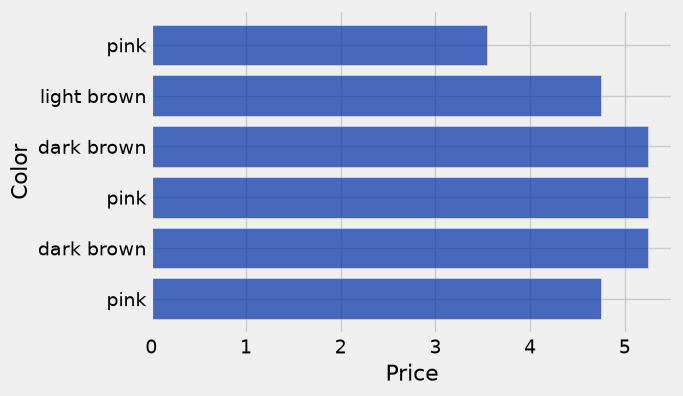

In [38]:
cones.barh('Color', 'Price')

In [40]:
cones.group('Flavor', np.average)

Flavor,Color average,Price average
bubblegum,,4.75
chocolate,,5.08333
strawberry,,4.4


In [33]:
cones.group('Flavor')

Flavor,count
bubblegum,1
chocolate,3
strawberry,2


Census data from 2019. Description of the data is located at https://www2.census.gov/programs-surveys/popest/technical-documentation/file-layouts/2010-2019/nc-est2019-agesex-res.pdf

In [3]:
full_census = Table.read_table('nc-est2019-agesex-res.csv')
full_census.show(4)

SEX,AGE,CENSUS2010POP,ESTIMATESBASE2010,POPESTIMATE2010,POPESTIMATE2011,POPESTIMATE2012,POPESTIMATE2013,POPESTIMATE2014,POPESTIMATE2015,POPESTIMATE2016,POPESTIMATE2017,POPESTIMATE2018,POPESTIMATE2019
0,0,3944153,3944160,3951430,3963092,3926570,3931258,3954787,3983981,3954773,3893990,3815343,3783052
0,1,3978070,3978090,3957730,3966225,3977549,3942698,3948891,3973133,4002903,3972711,3908830,3829599
0,2,4096929,4096939,4090621,3970654,3978925,3991740,3958711,3966321,3991349,4020045,3987032,3922044
0,3,4119040,4119051,4111688,4101644,3981531,3991017,4005928,3974351,3982984,4006946,4033038,3998665


In [16]:
# I want to make a table that only has FEMALE ('SEX' = 2) and I only them from the year 2017
females_2017 = full_census.where('SEX', 2).select('AGE', 'POPESTIMATE2017').where('AGE', are.below(999))
females_2017.show(3)

AGE,POPESTIMATE2017
0,1902229
1,1942553
2,1964591


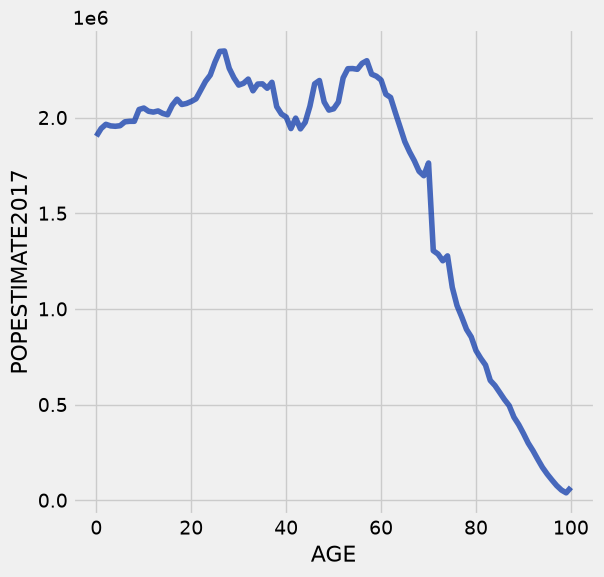

In [17]:
females_2017.plot('AGE', 'POPESTIMATE2017')

In [23]:
birth_years = 2017 - females_2017.column('AGE')

AGE,POPESTIMATE2017,Birth Year
0,1902229,2017
1,1942553,2016
2,1964591,2015


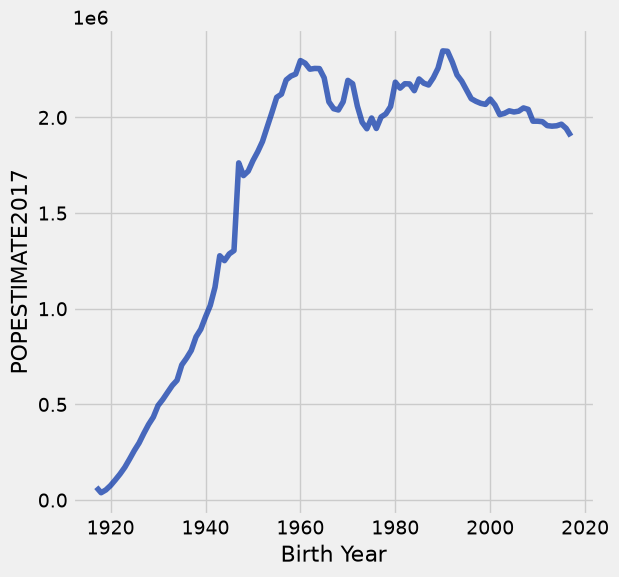

In [25]:
# What if I want to plot based on birth year rather than AGE?
female_birth_years = females_2017.with_column('Birth Year', birth_years)
female_birth_years.show(3)
female_birth_years.plot('Birth Year', 'POPESTIMATE2017')

In [26]:
males_2017 = full_census.where('SEX', 1).select('AGE', 'POPESTIMATE2017').where('AGE', are.below(999))
males_2017.show(3)

AGE,POPESTIMATE2017
0,1991761
1,2030158
2,2055454


In [27]:
men_and_women = Table().with_columns('AGE', males_2017.column('AGE'), 
                                     'Men in 2017', males_2017.column('POPESTIMATE2017'), 
                                     'Women in 2017', females_2017.column('POPESTIMATE2017'))

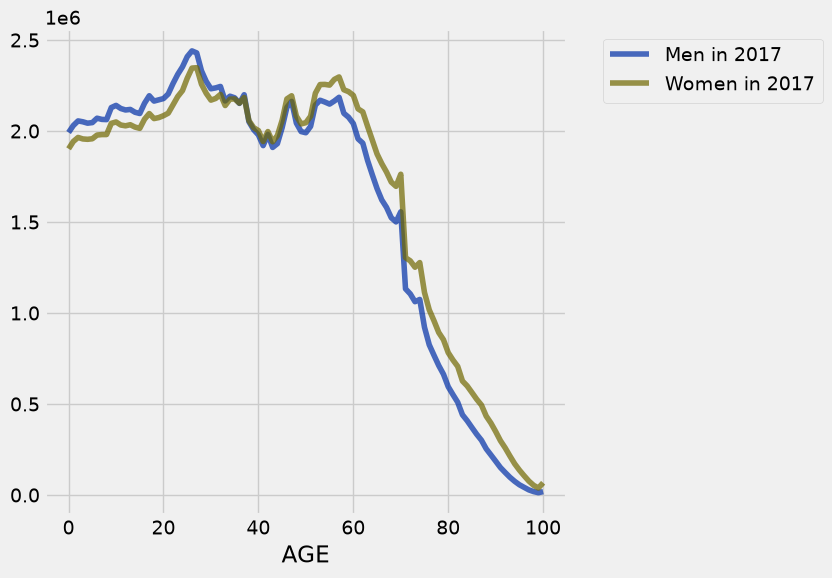

In [29]:
men_and_women.plot('AGE')

In [31]:
males_2017.column('POPESTIMATE2017') - females_2017.column('POPESTIMATE2017')

array([  89532,   87605,   90863,   94256,   88632,   88886,   92668,
         83503,   82096,   86711,   91104,   90722,   87016,   84053,
         81433,   81605,   87653,   97726,   96050,   97663,   94091,
        105599,  117077,  121984,  130502,  118548,   94435,   81263,
         73616,   65608,   62436,   58070,   43872,   25306,   16306,
          6314,   -1455,   14969,   -5956,  -11109,  -23858,  -22654,
        -16273,  -31189,  -44389,  -40778,  -46339,  -30801,  -38218,
        -42137,  -55331,  -55823,  -64640,  -86241,  -96742, -104245,
       -118517, -112045, -129223, -140484, -155018, -164876, -171879,
       -187517, -190811, -190056, -199349, -194149, -196013, -195498,
       -206402, -171239, -181546, -189242, -202667, -191163, -191958,
       -189722, -181320, -189602, -187045, -190258, -197105, -185528,
       -191289, -192459, -192351, -193259, -179636, -174983, -162908,
       -147619, -135386, -116963,  -96452,  -80515,  -63801,  -48484,
        -34385,  -26

In [13]:
everyone_2017 = full_census.where('SEX', 0).select('AGE', 'POPESTIMATE2017')
everyone_2017.show(3)

AGE,POPESTIMATE2017
0,3893990
1,3972711
2,4020045


In [14]:
1902229 + 1991761

3893990

### Lecture 5 Survey
https://forms.gle/tASMYkYq7FDpYtkQ8

### Visualizing Distributions

In [41]:
top_movies = Table.read_table('top_movies_2017.csv')
top_movies.show(6)

Title,Studio,Gross,Gross (Adjusted),Year
Gone with the Wind,MGM,198676459,1796176700,1939
Star Wars,Fox,460998007,1583483200,1977
The Sound of Music,Fox,158671368,1266072700,1965
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982
Titanic,Paramount,658672302,1204368000,1997
The Ten Commandments,Paramount,65500000,1164590000,1956


In [47]:
ages = 2026 - top_movies.column('Year')
top_movies = top_movies.with_column('Age', ages)

In [48]:
top_movies.show(3)

Title,Studio,Gross,Gross (Adjusted),Year,Age
Gone with the Wind,MGM,198676459,1796176700,1939,87
Star Wars,Fox,460998007,1583483200,1977,49
The Sound of Music,Fox,158671368,1266072700,1965,61


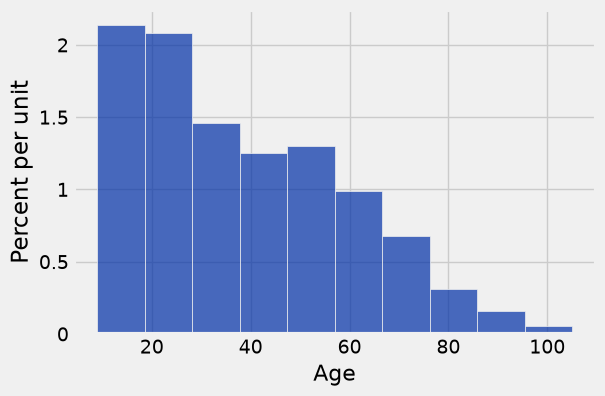

In [49]:
top_movies.hist('Age')